In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# -- Device --
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We are using device:", device)

# -- Transforms --
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    # data augmentation: 1. flip horizontal 2. rotate five degrees 3. zoom 4. translate
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -- Settings --
SAVE_PATH = '/content/drive/MyDrive/resnet18_face_binary.pth'
EPOCHS = 20
LR = 1e-4

# map text labels to binary targets (0 = simple, 1 = complex)
LABEL_MAP = {'simple': 0.0, 'complex': 1.0}

# -- Dataset --
class MakeupDataSet(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        image = self.transform(image)

        # CHANGED: use face-specific binary label
        label = torch.tensor(
            LABEL_MAP[row['face_label']],
            dtype=torch.float32
        )

        return image, label

# -- Load data --

# CHANGED: use cropped face images
IMG_DIR = '/content/drive/MyDrive/makeup/face'

# CHANGED: use new region-specific binary CSV
CSV_PATH = '/content/complexity_labels_region_binary.csv'

df = pd.read_csv(CSV_PATH)
df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

missing = df[~df["image_path"].apply(os.path.exists)]

print("Missing images:", len(missing))
print(missing["filename"].tolist())

df = df[df["image_path"].apply(os.path.exists)].copy().reset_index(drop=True)

# CHANGED: use face_label instead of complexity_label
print(df['face_label'].value_counts())

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['face_label']
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

train_loader = DataLoader(
    MakeupDataSet(train_df, IMG_DIR, train_tf),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    MakeupDataSet(val_df, IMG_DIR, val_tf),
    batch_size=32,
    shuffle=False
)

# -- Model --
model = models.resnet18(weights='IMAGENET1K_V1')

# output 1 raw logit for binary classification
# BCEWithLogitsLoss applies sigmoid internally
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 1)
)

# freeze everything first, then unfreeze layer4
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# BCEWithLogitsLoss for binary classification
# Experiment 1: NO weighted loss
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4
)

# -- Training loop --
best_val_acc = 0.0

for epoch in range(EPOCHS):

    # training phase
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    # validation phase
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)

            val_loss += criterion(outputs, labels).item() * len(labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(
                preds.squeeze(1).cpu().numpy()
            )

            all_labels.extend(
                labels.squeeze(1).cpu().numpy()
            )

    train_loss_avg = train_loss / len(train_df)
    val_loss_avg = val_loss / len(val_df)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss: {train_loss_avg:.4f} | "
        f"val_loss: {val_loss_avg:.4f} | "
        f"train_acc: {train_acc:.3f} | "
        f"val_acc: {val_acc:.3f}"
    )

    # save model if val_acc improves
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print(
            f"  -> best model saved "
            f"(val_acc={val_acc:.3f})"
        )

print(
    f"\nDone! Best validation accuracy: "
    f"{best_val_acc:.3f}"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
We are using device: cuda
Missing images: 2
['7a6efe107c6d7cdc5dd77d2af63b5bcb.png', 'vHX704.png']
face_label
simple     1647
complex    1070
Name: count, dtype: int64
Training images: 2173
Validation images: 544
Epoch 01/20 | train_loss: 0.7169 | val_loss: 0.6570 | train_acc: 0.567 | val_acc: 0.616
  -> best model saved (val_acc=0.616)
Epoch 02/20 | train_loss: 0.6891 | val_loss: 0.6487 | train_acc: 0.585 | val_acc: 0.618
  -> best model saved (val_acc=0.618)
Epoch 03/20 | train_loss: 0.6852 | val_loss: 0.6389 | train_acc: 0.604 | val_acc: 0.636
  -> best model saved (val_acc=0.636)
Epoch 04/20 | train_loss: 0.6653 | val_loss: 0.6380 | train_acc: 0.599 | val_acc: 0.623
Epoch 05/20 | train_loss: 0.6566 | val_loss: 0.6313 | train_acc: 0.621 | val_acc: 0.643
  -> best model saved (val_acc=0.643)
Epoch 06/20 | train_loss: 0.6424 | val_loss: 0.6270 | train_acc: 0

In [3]:
model.load_state_dict(
    torch.load(SAVE_PATH, map_location=device)
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

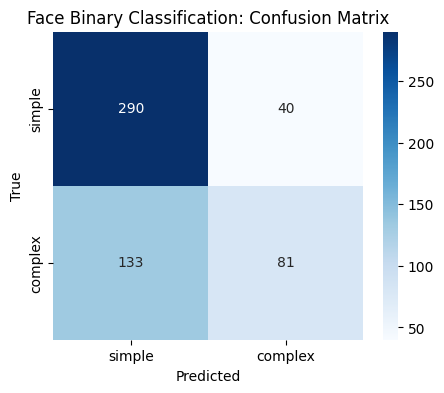

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        all_preds.extend(
            preds.squeeze(1).cpu().numpy()
        )

        all_labels.extend(
            labels.squeeze(1).cpu().numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

labels_names = [
    'simple',
    'complex'
]

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels_names,
    yticklabels=labels_names,
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Face Binary Classification: Confusion Matrix'
)

plt.show()